# Human Activity Recognition from Smartphone Sensors
## PCA, KMeans Clustering and Supervised Classification

### Goal

This notebook studies whether smartphone sensor features reveal human activities in two ways:

1. **Unsupervised exploration:** PCA and KMeans discover activity-like groups without using the activity labels while building clusters.
2. **Supervised prediction:** Logistic Regression, Random Forest and XGBoost predict activity labels for volunteers in the official unseen test set.

The dataset contains motion windows from **30 volunteers** performing six activities. Each row contains **561 prepared sensor features**. The official train/test split is preserved: model tuning happens only with the training volunteers, and the test set is checked only at the final stage.

Source: [UCI Human Activity Recognition Using Smartphones](https://archive.ics.uci.edu/dataset/240/human%2Bactivity%2Brecognition%2Busing%2Bsmartphones)

```python
# Run only if needed:
# !pip install umap-learn xgboost -q
```


## 1. Load the data

In [34]:
from pathlib import Path
import pandas as pd

train = pd.read_csv("../data/sensor_train.csv")
test = pd.read_csv("../data/sensor_test.csv")

feature_columns = [c for c in train.columns if c not in ["subject", "Activity"]]

summary = pd.DataFrame({
    "Set": ["Train", "Test"],
    "Rows": [len(train), len(test)],
    "Sensor features": [len(feature_columns), len(feature_columns)],
    "Volunteers": [train["subject"].nunique(), test["subject"].nunique()],
    "Activities": [train["Activity"].nunique(), test["Activity"].nunique()],
    "Missing values": [train.isna().sum().sum(), test.isna().sum().sum()]
})

summary


,Set,Rows,Sensor features,Volunteers,Activities,Missing values
0,Train,7352,561,21,6,0
1,Test,2947,561,9,6,0


In [35]:
train["Activity"].value_counts().rename_axis("Activity").to_frame("Train rows")


,Train rows
Activity,
LAYING,1407
STANDING,1374
SITTING,1286
WALKING,1226
WALKING_UPSTAIRS,1073
WALKING_DOWNSTAIRS,986


In [36]:
X_train = train[feature_columns]
y_train = train["Activity"]
groups_train = train["subject"]

X_test = test[feature_columns]
y_test = test["Activity"]

X_train.shape, X_test.shape


((7352, 561), (2947, 561))

The `Activity` label is used only after clustering for evaluation, and later as the target for classification. The `subject` column identifies volunteers and is used to make cross-validation group-aware.

## 2. PCA dimensionality reduction

In [37]:
import numpy as np
from sklearn.decomposition import PCA

pca_full = PCA(random_state=42)
pca_full.fit(X_train)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

pca_report = pd.DataFrame({
    "PCA components": [2, 5, 10, 11, 36, 50, 69],
    "Variance retained (%)": [
        cumulative_variance[1] * 100,
        cumulative_variance[4] * 100,
        cumulative_variance[9] * 100,
        cumulative_variance[10] * 100,
        cumulative_variance[35] * 100,
        cumulative_variance[49] * 100,
        cumulative_variance[68] * 100
    ]
}).round(2)

pca_report


,PCA components,Variance retained (%)
0,2,67.47
1,5,75.16
2,10,80.50
3,11,81.27
4,36,90.55
5,50,93.09
6,69,95.23


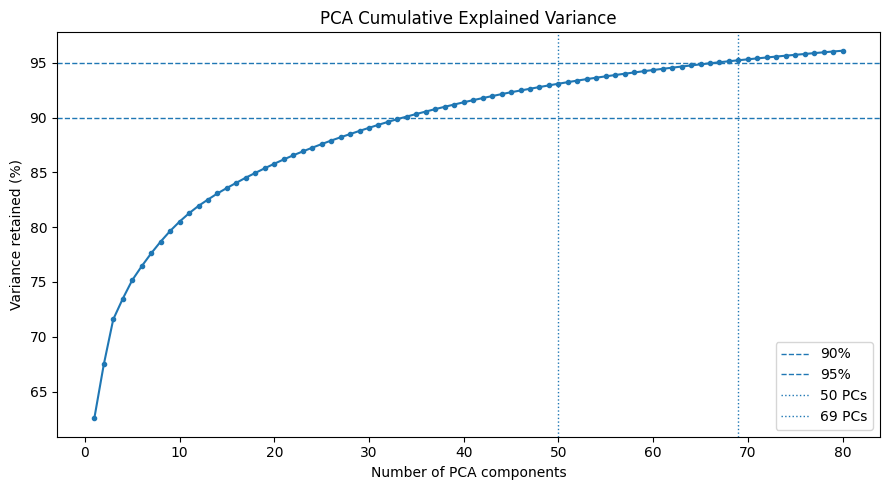

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, 81), cumulative_variance[:80] * 100, marker="o", markersize=3)
ax.axhline(90, linestyle="--", linewidth=1, label="90%")
ax.axhline(95, linestyle="--", linewidth=1, label="95%")
ax.axvline(50, linestyle=":", linewidth=1, label="50 PCs")
ax.axvline(69, linestyle=":", linewidth=1, label="69 PCs")
ax.set_title("PCA Cumulative Explained Variance")
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Variance retained (%)")
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()


We report PCA with **36**, **50** and **69** components for clustering. For the supervised models, we use only **PCA 69**, because it preserves approximately 95% of training variation while still reducing the original 561 features heavily.

## 3. KMeans clustering after PCA

In [39]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

clustering_results = []
cluster_labels = {}
pca_spaces = {}

for n_components in [36, 50, 69]:
    pca = PCA(n_components=n_components, random_state=42)
    X_pca = pca.fit_transform(X_train)

    kmeans = KMeans(n_clusters=6, n_init=20, random_state=42)
    clusters = kmeans.fit_predict(X_pca)

    clustering_results.append({
        "PCA components": n_components,
        "Variance retained (%)": pca.explained_variance_ratio_.sum() * 100,
        "Silhouette": silhouette_score(X_pca, clusters, sample_size=3000, random_state=42),
        "ARI": adjusted_rand_score(y_train, clusters),
        "NMI": normalized_mutual_info_score(y_train, clusters)
    })

    cluster_labels[n_components] = clusters
    pca_spaces[n_components] = X_pca

clustering_results = pd.DataFrame(clustering_results).round(3)
clustering_results


,PCA components,Variance retained (%),Silhouette,ARI,NMI
0,36,90.548,0.182,0.455,0.584
1,50,93.086,0.170,0.456,0.585
2,69,95.226,0.160,0.455,0.584


In [40]:
best_pca_for_clustering = int(
    clustering_results.sort_values("Silhouette", ascending=False).iloc[0]["PCA components"]
)

X_cluster_pca = pca_spaces[best_pca_for_clustering]
best_clusters = cluster_labels[best_pca_for_clustering]

best_pca_for_clustering


36

In [41]:
cluster_activity = pd.crosstab(
    pd.Series(best_clusters, name="KMeans cluster"),
    y_train.reset_index(drop=True).rename("Known activity"),
    normalize="index"
).mul(100).round(1)

cluster_activity


Known activity,LAYING,SITTING,STANDING,WALKING,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS
KMeans cluster,,,,,,
0,0.7,0.1,0.0,37.6,8.7,53.0
1,0.0,49.2,50.8,0.0,0.0,0.0
2,0.0,0.0,0.0,40.1,44.5,15.4
3,16.8,35.5,47.6,0.0,0.0,0.0
4,96.1,3.9,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,23.8,64.3,11.9


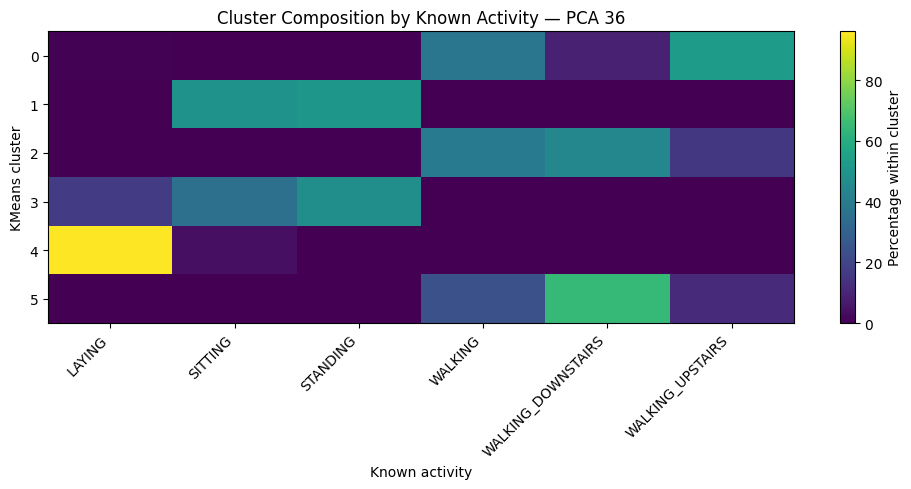

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
image = ax.imshow(cluster_activity.values, aspect="auto")
ax.set_title(f"Cluster Composition by Known Activity — PCA {best_pca_for_clustering}")
ax.set_xlabel("Known activity")
ax.set_ylabel("KMeans cluster")
ax.set_xticks(range(len(cluster_activity.columns)))
ax.set_xticklabels(cluster_activity.columns, rotation=45, ha="right")
ax.set_yticks(range(len(cluster_activity.index)))
ax.set_yticklabels(cluster_activity.index)
ax.grid(False)
plt.colorbar(image, ax=ax, label="Percentage within cluster")
plt.tight_layout()
plt.show()


**Silhouette** measures natural cluster separation without using activity labels. **ARI** and **NMI** check afterward how closely the discovered clusters align with the real six activities.

## 4. PCA, t-SNE and UMAP visualisation

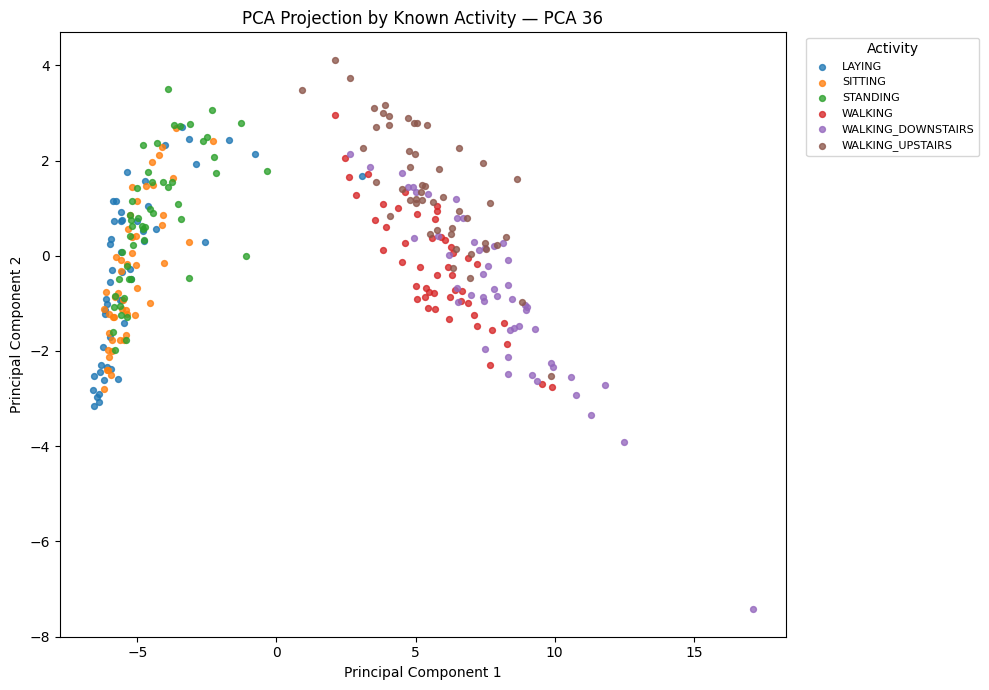

In [43]:
def plot_embedding(embedding, labels, title, x_label, y_label, legend_title):
    fig, ax = plt.subplots(figsize=(10, 7))

    for label in sorted(pd.Series(labels).unique()):
        mask = pd.Series(labels).to_numpy() == label
        ax.scatter(embedding[mask, 0], embedding[mask, 1], s=18, alpha=0.78, label=label)

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(False)
    ax.legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()


visual_sample = (
    train.groupby("Activity", group_keys=False)
    .sample(n=50, random_state=42)
    .sample(frac=1, random_state=42)
)

visual_index = visual_sample.index
visual_activities = visual_sample["Activity"]
X_visual = X_cluster_pca[visual_index]
visual_clusters = best_clusters[visual_index]

plot_embedding(
    X_visual[:, :2],
    visual_activities,
    f"PCA Projection by Known Activity — PCA {best_pca_for_clustering}",
    "Principal Component 1",
    "Principal Component 2",
    "Activity"
)


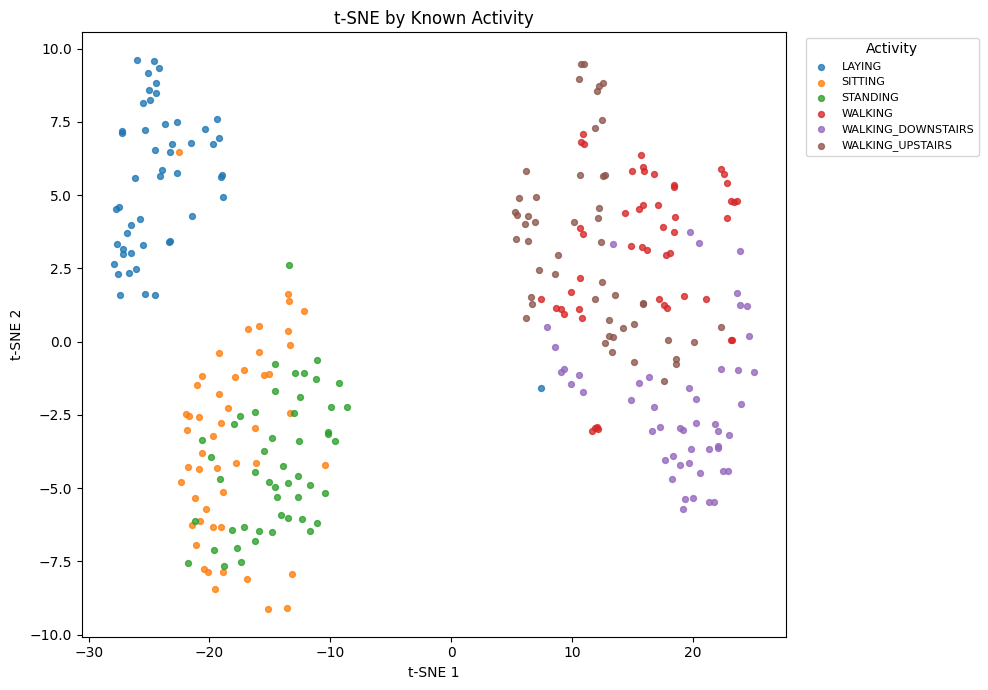

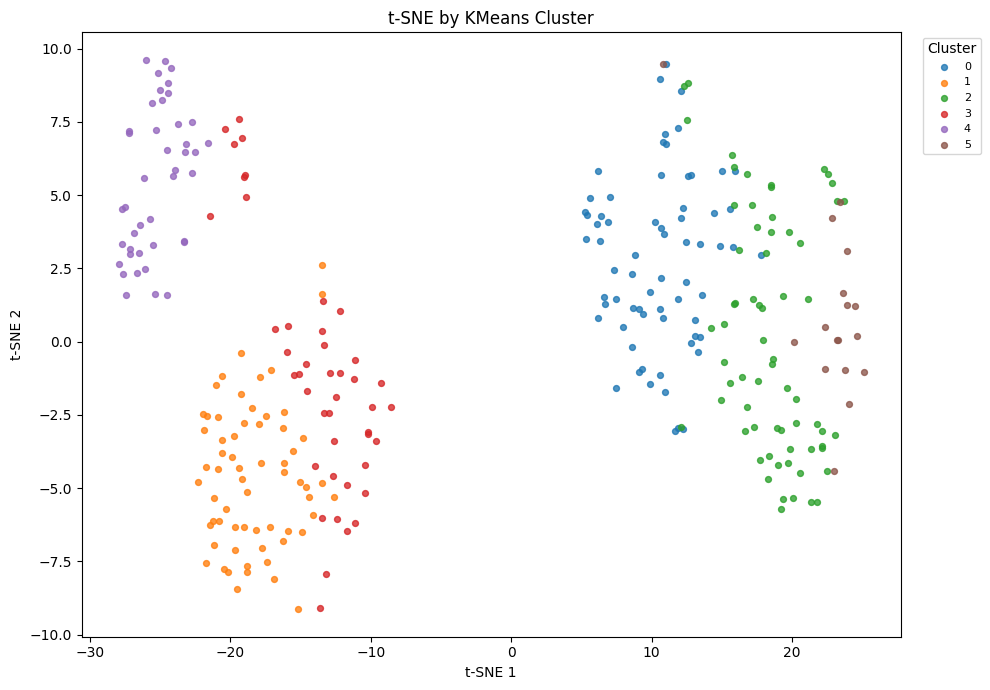

In [44]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    max_iter=500,
    random_state=42
)

X_tsne = tsne.fit_transform(X_visual)

plot_embedding(X_tsne, visual_activities, "t-SNE by Known Activity", "t-SNE 1", "t-SNE 2", "Activity")
plot_embedding(X_tsne, visual_clusters, "t-SNE by KMeans Cluster", "t-SNE 1", "t-SNE 2", "Cluster")


In [45]:
!pip install umap-learn



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\zirad\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


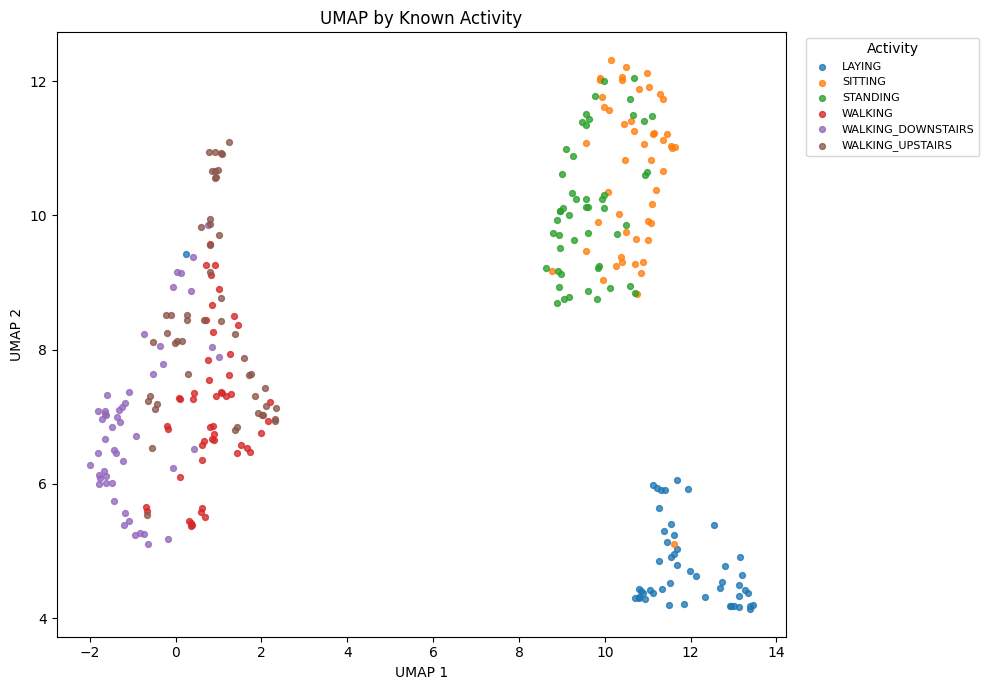

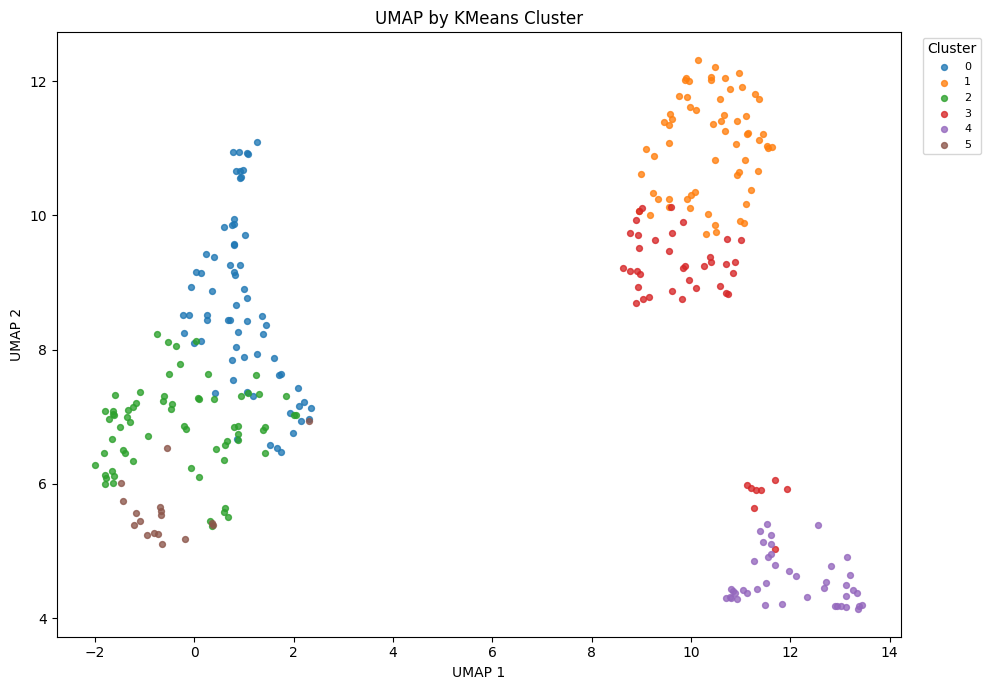

In [46]:
# UMAP can take longer on its first run while the library compiles in a fresh environment.
RUN_UMAP = True

if RUN_UMAP:
    import umap.umap_ as umap

    umap_model = umap.UMAP(
        n_neighbors=15,
        min_dist=0.20,
        n_epochs=100,
        random_state=42
    )
    X_umap = umap_model.fit_transform(X_visual)

    plot_embedding(X_umap, visual_activities, "UMAP by Known Activity", "UMAP 1", "UMAP 2", "Activity")
    plot_embedding(X_umap, visual_clusters, "UMAP by KMeans Cluster", "UMAP 1", "UMAP 2", "Cluster")
else:
    print("UMAP code is ready. Change RUN_UMAP to True when you want to generate the UMAP plots.")


KMeans is trained on PCA features. t-SNE and UMAP are used only to display the activity structure and discovered clusters in two dimensions.

## 5. Supervised classification with PCA 69

In [47]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

encoder.classes_


array(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], dtype=object)

In [48]:
from joblib import Memory
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

cv = GroupKFold(n_splits=3)
cache = Memory("har_pipeline_cache", verbose=0)

results = []
searches = {}


PCA is inside each pipeline, so it is fitted only within the training portion of every cross-validation fold. `GroupKFold` keeps the recordings of one volunteer together during tuning.

### Logistic Regression

In [49]:
from sklearn.linear_model import LogisticRegression

logistic = Pipeline([
    ("pca", PCA(n_components=69, random_state=42)),
    ("model", LogisticRegression(max_iter=2000))
], memory=cache)

logistic_search = RandomizedSearchCV(
    logistic,
    {"model__C": [0.001, 0.01, 0.1, 1, 10, 100]},
    n_iter=3,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=1,
    refit=True
)

logistic_search.fit(X_train, y_train_encoded, groups=groups_train)
logistic_pred = logistic_search.predict(X_test)

results.append({
    "Model": "Logistic Regression",
    "CV Macro F1": logistic_search.best_score_,
    "Test Accuracy": accuracy_score(y_test_encoded, logistic_pred),
    "Test Macro F1": f1_score(y_test_encoded, logistic_pred, average="macro")
})

searches["Logistic Regression"] = logistic_search
logistic_search.best_params_


{'model__C': 100}

### Random Forest

In [50]:
from sklearn.ensemble import RandomForestClassifier

forest = Pipeline([
    ("pca", PCA(n_components=69, random_state=42)),
    ("model", RandomForestClassifier(random_state=42, n_jobs=1))
], memory=cache)

forest_search = RandomizedSearchCV(
    forest,
    {
        "model__n_estimators": [50, 80, 120],
        "model__max_depth": [None, 15, 25],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2"]
    },
    n_iter=2,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=1,
    refit=True
)

forest_search.fit(X_train, y_train_encoded, groups=groups_train)
forest_pred = forest_search.predict(X_test)

results.append({
    "Model": "Random Forest",
    "CV Macro F1": forest_search.best_score_,
    "Test Accuracy": accuracy_score(y_test_encoded, forest_pred),
    "Test Macro F1": f1_score(y_test_encoded, forest_pred, average="macro")
})

searches["Random Forest"] = forest_search
forest_search.best_params_


{'model__n_estimators': 80,
 'model__min_samples_leaf': 2,
 'model__max_features': 'log2',
 'model__max_depth': 25}

### XGBoost

In [51]:
from xgboost import XGBClassifier

xgb = Pipeline([
    ("pca", PCA(n_components=69, random_state=42)),
    ("model", XGBClassifier(
        objective="multi:softprob",
        num_class=6,
        eval_metric="mlogloss",
        tree_method="hist",
        max_bin=128,
        random_state=42,
        n_jobs=1
    ))
], memory=cache)

xgb_search = RandomizedSearchCV(
    xgb,
    {
        "model__n_estimators": [30, 50, 80],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.10, 0.20],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    },
    n_iter=2,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=1,
    refit=True
)

xgb_search.fit(X_train, y_train_encoded, groups=groups_train)
xgb_pred = xgb_search.predict(X_test)

results.append({
    "Model": "XGBoost",
    "CV Macro F1": xgb_search.best_score_,
    "Test Accuracy": accuracy_score(y_test_encoded, xgb_pred),
    "Test Macro F1": f1_score(y_test_encoded, xgb_pred, average="macro")
})

searches["XGBoost"] = xgb_search
xgb_search.best_params_


{'model__subsample': 0.8,
 'model__n_estimators': 50,
 'model__max_depth': 3,
 'model__learning_rate': 0.2,
 'model__colsample_bytree': 1.0}

## 6. Final test-set results

In [52]:
results_table = (
    pd.DataFrame(results)
    .sort_values("Test Macro F1", ascending=False)
    .reset_index(drop=True)
)

results_table.round(4)


,Model,CV Macro F1,Test Accuracy,Test Macro F1
0,Logistic Regression,0.9002,0.9464,0.9455
1,Random Forest,0.8664,0.9084,0.9062
2,XGBoost,0.8671,0.9036,0.9014


In [53]:
winner = results_table.loc[0, "Model"]
final_model = searches[winner]
final_prediction = final_model.predict(X_test)

winner


'Logistic Regression'

In [54]:
final_report = classification_report(
    y_test_encoded,
    final_prediction,
    target_names=encoder.classes_,
    output_dict=True
)

pd.DataFrame(final_report).transpose().round(3)


,precision,recall,f1-score,support
LAYING,0.998,1.000,0.999,537.000
SITTING,0.941,0.904,0.922,491.000
STANDING,0.921,0.947,0.934,532.000
WALKING,0.909,0.986,0.946,496.000
WALKING_DOWNSTAIRS,0.961,0.950,0.956,420.000
WALKING_UPSTAIRS,0.952,0.883,0.916,471.000
accuracy,0.946,0.946,0.946,0.946
macro avg,0.947,0.945,0.946,2947.000
weighted avg,0.947,0.946,0.946,2947.000


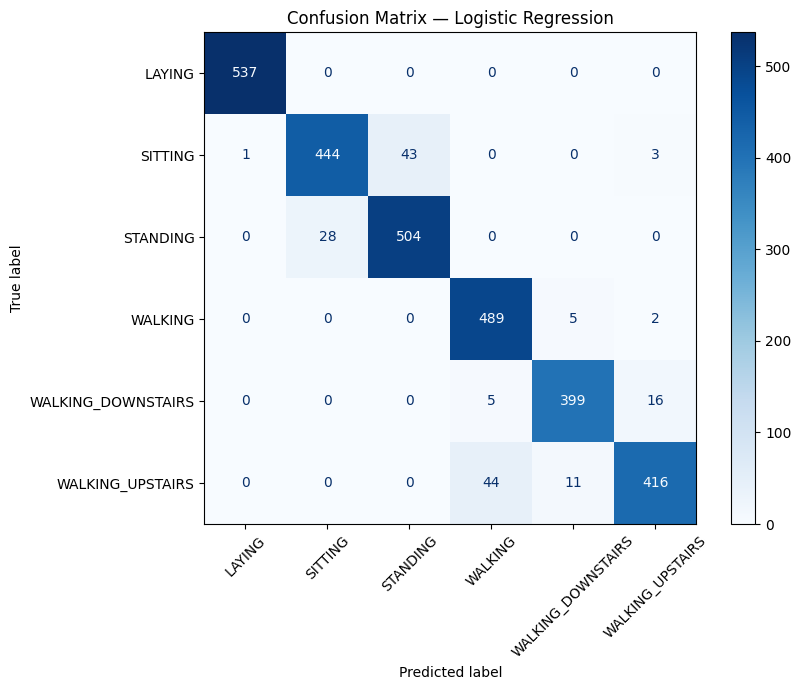

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    final_prediction,
    display_labels=encoder.classes_,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax
)

ax.set_title(f"Confusion Matrix — {winner}")
ax.grid(False)
plt.tight_layout()
plt.show()


## Conclusion

This notebook connects unsupervised and supervised learning in one activity-recognition workflow:

- PCA reduces 561 sensor features to compact representations.
- KMeans investigates whether activity patterns can be discovered without target labels.
- Silhouette, ARI and NMI evaluate the clustering.
- t-SNE visualises known activities and discovered groups; a ready-to-run UMAP cell is included for an additional nonlinear visual.
- PCA with 69 components is used consistently for classification.
- Logistic Regression, Random Forest and XGBoost are tuned with group-aware cross-validation.
- The official test volunteers are used only for the final evaluation.

### References

- [UCI HAR dataset](https://archive.ics.uci.edu/dataset/240/human%2Bactivity%2Brecognition%2Busing%2Bsmartphones)
- [scikit-learn documentation](https://scikit-learn.org/stable/)
- [XGBoost documentation](https://xgboost.readthedocs.io/)
